In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

After Importing the libraries lets load our data


In [3]:
Housing_price=r"C:\Users\ADMIN\Downloads\Housing.csv"
housing=pd.read_csv(Housing_price)
housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


Now we can see a short review of all our data lets start by checking for null values

In [4]:
housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

So from the info above we can see that there is no null values across all variables lets check for dupliicates as well


In [6]:
housing.duplicated().sum()

np.int64(0)

There is no duplicate as well so lets dive into our data and check trends

In [7]:
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


From here we can see all our variables so lets check how they influence each other Lets start with the area and badrooms lets visualize this to see their relatioship

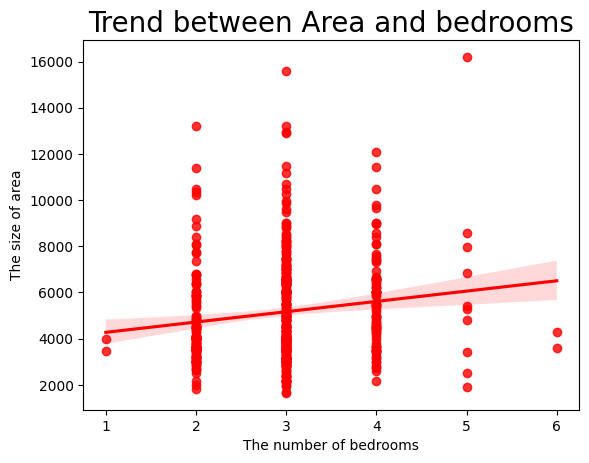

In [22]:
sns.regplot(x='bedrooms',y='area',data=housing,color='red')
plt.title('Trend between Area and bedrooms',fontsize=20)
plt.xlabel('The number of bedrooms')
plt.ylabel('The size of area')
plt.show()

In [20]:
housing['bedrooms'].value_counts()

bedrooms
3    300
2    136
4     95
5     10
6      2
1      2
Name: count, dtype: int64

So with this visual we can see that the number of bedrooms increase with the size of the area and we can also see that in our data most houses have 3 bedrooms
So lets continue without categorical variables(mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furishigstatus) All this can be converted to numerical variables as they are ahuge factors in getting the price

In [5]:
new_df=housing[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']].replace({'yes':0,'no':1})

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_13820\2901557828.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df=housing[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']].replace({'yes':0,'no':1})


In [6]:
housing[['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']]=new_df

In [10]:
housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,0,1,1,1,0,2,0,furnished
1,12250000,8960,4,4,4,0,1,1,1,0,3,1,furnished
2,12250000,9960,3,2,2,0,1,0,1,1,2,0,semi-furnished
3,12215000,7500,4,2,2,0,1,0,1,0,3,0,furnished
4,11410000,7420,4,1,2,0,0,0,1,0,2,1,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,0,1,0,1,1,2,1,unfurnished
541,1767150,2400,3,1,1,1,1,1,1,1,0,1,semi-furnished
542,1750000,3620,2,1,1,0,1,1,1,1,0,1,unfurnished
543,1750000,2910,3,1,1,1,1,1,1,1,0,1,furnished


In [7]:
new_fur=housing['furnishingstatus'].map({'furnished':0,'semi-furnished':1,'unfurnished':2})

In [8]:
housing['furnishingstatus']=new_fur

In [9]:
housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,0,1,1,1,0,2,0,0
1,12250000,8960,4,4,4,0,1,1,1,0,3,1,0
2,12250000,9960,3,2,2,0,1,0,1,1,2,0,1
3,12215000,7500,4,2,2,0,1,0,1,0,3,0,0
4,11410000,7420,4,1,2,0,0,0,1,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,0,1,0,1,1,2,1,2
541,1767150,2400,3,1,1,1,1,1,1,1,0,1,1
542,1750000,3620,2,1,1,0,1,1,1,1,0,1,2
543,1750000,2910,3,1,1,1,1,1,1,1,0,1,0


Now that all the categorical variables has been converted lets set an index and find the correlatio to find the suited indepedent variables

In [14]:
housing.index = range(1, len(housing) + 1)

In [10]:
housing.corr()['price'].sort_values(ascending=False)

price               1.000000
area                0.535997
bathrooms           0.517545
stories             0.420712
parking             0.384394
bedrooms            0.366494
hotwaterheating    -0.093073
basement           -0.187057
guestroom          -0.255517
mainroad           -0.296898
furnishingstatus   -0.304721
prefarea           -0.329777
airconditioning    -0.452954
Name: price, dtype: float64

So from this info we can confirm that price and area are the best predictors as an independent variable 

In [43]:
housing.to_csv(r"C:\Users\ADMIN\Downloads\cleaned_housing_dataset.csv")
              

In [16]:
housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
1,13300000,7420,4,2,3,0,1,1,1,0,2,0,0
2,12250000,8960,4,4,4,0,1,1,1,0,3,1,0
3,12250000,9960,3,2,2,0,1,0,1,1,2,0,1
4,12215000,7500,4,2,2,0,1,0,1,0,3,0,0
5,11410000,7420,4,1,2,0,0,0,1,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,1820000,3000,2,1,1,0,1,0,1,1,2,1,2
542,1767150,2400,3,1,1,1,1,1,1,1,0,1,1
543,1750000,3620,2,1,1,0,1,1,1,1,0,1,2
544,1750000,2910,3,1,1,1,1,1,1,1,0,1,0


In [15]:
room=housing['bathrooms'].value_counts()

In [16]:
room

bathrooms
1    401
2    133
3     10
4      1
Name: count, dtype: int64

# Performing a univariate analysis
So lets check how many bedrooms most houses have


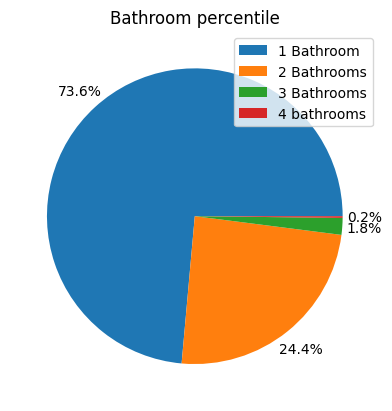

In [22]:
plt.pie(x=room,data=housing,autopct='%1.1f%%',pctdistance=1.15)
plt.legend(labels=['1 Bathroom','2 Bathrooms','3 Bathrooms','4 bathrooms'])
plt.title('Bathroom percentile')
plt.show()

So we can see from this visual that 73.6% of the houses has only 1 bathroom  so this is a univariate analysis

In [23]:
housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,0,1,1,1,0,2,0,0
1,12250000,8960,4,4,4,0,1,1,1,0,3,1,0
2,12250000,9960,3,2,2,0,1,0,1,1,2,0,1
3,12215000,7500,4,2,2,0,1,0,1,0,3,0,0
4,11410000,7420,4,1,2,0,0,0,1,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,0,1,0,1,1,2,1,2
541,1767150,2400,3,1,1,1,1,1,1,1,0,1,1
542,1750000,3620,2,1,1,0,1,1,1,1,0,1,2
543,1750000,2910,3,1,1,1,1,1,1,1,0,1,0


# Bivariate Analysis
Lets see how the number of rooms influence the price

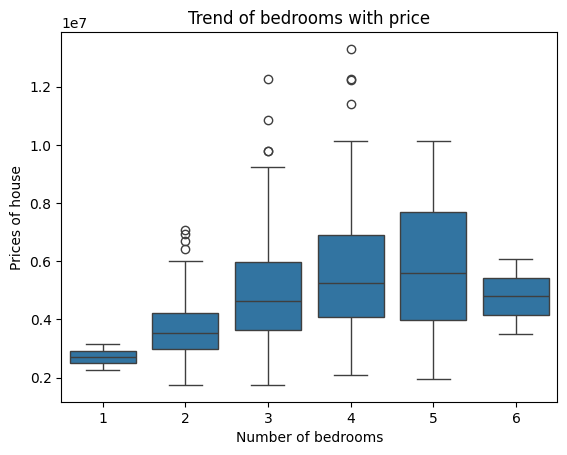

In [24]:
sns.boxplot(x='bedrooms',y='price',data=housing)
plt.title('Trend of bedrooms with price')
plt.xlabel('Number of bedrooms')
plt.ylabel('Prices of house')
plt.show()

In [26]:
housing.corr()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,1.000000,0.535997,0.366494,0.517545,0.420712,-0.296898,-0.255517,-0.187057,-0.093073,-0.452954,0.384394,-0.329777,-0.304721
area,0.535997,1.000000,0.151858,0.193820,0.083996,-0.288874,-0.140297,-0.047417,0.009229,-0.222393,0.352980,-0.234779,-0.171445
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.012033,-0.080549,-0.097312,-0.046049,-0.160603,0.139270,-0.079023,-0.123244
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,-0.042398,-0.126469,-0.102106,-0.067159,-0.186915,0.177496,-0.063472,-0.143559
stories,0.420712,0.083996,0.408564,0.326165,1.000000,-0.121706,-0.043538,0.172394,-0.018847,-0.293602,0.045547,-0.044425,-0.104672
mainroad,-0.296898,-0.288874,0.012033,-0.042398,-0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,-0.204433,0.199876,0.156726
guestroom,-0.255517,-0.140297,-0.080549,-0.126469,-0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,-0.037466,0.160897,0.118328
basement,-0.187057,-0.047417,-0.097312,-0.102106,0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,-0.051497,0.228083,0.112831
hotwaterheating,-0.093073,0.009229,-0.046049,-0.067159,-0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,-0.067864,-0.059411,0.031628
airconditioning,-0.452954,-0.222393,-0.160603,-0.186915,-0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,-0.159173,0.117382,0.150477


In [27]:
housing['bedrooms'].describe()

count    545.000000
mean       2.965138
std        0.738064
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        6.000000
Name: bedrooms, dtype: float64